### **Melbourne Housing Market Analysis: Exploring Factors Influencing Property Prices**

**Author:** Mahak Kar

**Project Type:** Python Portfolio Project

This notebook presents a comprehensive exploratory analysis of Melbourne's real estate market, featuring clean documentation, suburb-wise pricing trends, amenity impact studies, and data-driven insights into urban property valuation

**Objective-** The objective of this project is to perform an in-depth Exploratory Data Analysis (EDA) on the Melbourne Housing dataset to uncover key patterns and trends in the real estate market. This study aims to identify the critical factors influencing property prices, including suburb location, property size, number of rooms, proximity to schools, hospitals, and public transport. Through statistical analysis and data visualization, this project seeks to understand regional price variations across Melbourne's diverse suburbs and neighborhoods. The analysis also investigates the impact of property features such as building area, land size, garage type, heating type, and renovation history on market valuation. Ultimately, this project delivers actionable, data-driven insights to assist homebuyers, real estate agents, and property investors in making informed and confident decisions.

In [4]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

In [7]:
melb_df = pd.read_csv(r"C:\Users\Rahul\Downloads\Melbourne Housing Market Analysis and Price Trend Exploration.csv")
melb_df

,Suburb,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,...,Direction,FloorCount,WalkScore,SchoolNearby,HospitalNearby,PublicTransport,PropertyCondition,HeatingType,GarageType,RenovatedYear
0,Reservoir,1,u,NaN,S,hockingstuart,18/6/2016,16.5,3216,2.0,...,E,2.0,50.0,NaN,No,Yes,Poor,NaN,Carport,2003.0
1,Brunswick,2,t,2272643.0,S,Biggin,18/6/2016,4.0,3066,4.0,...,SW,3.0,77.0,Yes,No,NaN,Good,Solar,NaN,1998.0
2,Hawthorn,6,u,769385.0,PI,Marshall,3/12/2016,26.7,3209,2.0,...,NW,2.0,96.0,No,No,Yes,Excellent,Gas,NaN,2021.0
3,Malvern,1,t,1822138.0,SA,Barry,4/2/2017,NaN,3177,NaN,...,N,4.0,87.0,No,NaN,Yes,Average,NaN,Single,NaN
4,St Kilda,4,h,2267337.0,PI,Nelson,18/6/2016,16.8,3117,2.0,...,NW,3.0,50.0,No,No,Yes,Poor,Solar,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,South Yarra,1,u,1809049.0,VB,Nelson,4/2/2017,6.9,3057,4.0,...,NW,NaN,50.0,Yes,Yes,No,Good,Gas,Carport,NaN
1996,Essendon,1,u,2192517.0,S,Nelson,4/2/2017,29.0,3062,3.0,...,SE,3.0,NaN,No,Yes,No,Excellent,Gas,Double,2004.0
1997,Coburg,6,u,2504851.0,SA,Nelson,1/9/2018,11.1,3015,2.0,...,W,4.0,NaN,NaN,NaN,Yes,Average,Solar,Double,2004.0
1998,South Yarra,4,t,2624494.0,VB,hockingstuart,1/9/2018,13.6,3133,6.0,...,NW,2.0,92.0,No,No,Yes,Poor,NaN,Single,1996.0


#### **Dataset Column Description----------------------------------------------------------**

**Suburb** - Name of the suburb where the property is located

**Rooms** - Total number of rooms in the property

**Type** - Type of property (e.g., house, unit, townhouse)

**Price** - Sale price of the property (target variable)

**Method** - Method of sale (e.g., auction, private sale)

**SellerG** - Name of the real estate agent or agency

**Date** - Date on which the property was sold

**Distance** - Distance from the Melbourne CBD (in km)

**Postcode** - Postal code of the property location

**Bedroom2** - Number of bedrooms (alternate source/count)

**Bathroom** - Number of bathrooms in the property

**Car** - Number of car parking spots available

**Landsize** - Total land area of the property (in sqm)

**BuildingArea** - Total built-up area of the property (in sqm)

**YearBuilt** - Year in which the property was built

**CouncilArea** - Name of the local government/council area

**Lattitude** - Geographic latitude coordinate of the property

**Longtitude** - Geographic longitude coordinate of the property

**Regionname** - Broader region name within Melbourne

**Propertycount** - Number of properties in the same suburb

**Direction** - Directional location relative to Melbourne CBD (e.g., N, S, E, W)

**FloorCount** - Number of floors in the property

**WalkScore** - Walkability score of the property's location

**SchoolNearby** - Indicates whether a school is nearby

**HospitalNearby** - Indicates whether a hospital is nearby

**PublicTransport** - Availability of public transport near the property

**PropertyCondition** - Overall condition of the property (e.g., good, average, poor)

**HeatingType** - Type of heating system installed in the property

**GarageType** - Type of garage available (e.g., lock-up, open)

**RenovatedYear** - Year in which the property was last renovated

In [8]:
# Display the first five rows of the dataset to understand its structure,
# column names, and sample records before performing data analysis.

melb_df.head() 

,Suburb,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,...,Direction,FloorCount,WalkScore,SchoolNearby,HospitalNearby,PublicTransport,PropertyCondition,HeatingType,GarageType,RenovatedYear
0,Reservoir,1,u,NaN,S,hockingstuart,18/6/2016,16.5,3216,2.0,...,E,2.0,50.0,NaN,No,Yes,Poor,NaN,Carport,2003.0
1,Brunswick,2,t,2272643.0,S,Biggin,18/6/2016,4.0,3066,4.0,...,SW,3.0,77.0,Yes,No,NaN,Good,Solar,NaN,1998.0
2,Hawthorn,6,u,769385.0,PI,Marshall,3/12/2016,26.7,3209,2.0,...,NW,2.0,96.0,No,No,Yes,Excellent,Gas,NaN,2021.0
3,Malvern,1,t,1822138.0,SA,Barry,4/2/2017,NaN,3177,NaN,...,N,4.0,87.0,No,NaN,Yes,Average,NaN,Single,NaN
4,St Kilda,4,h,2267337.0,PI,Nelson,18/6/2016,16.8,3117,2.0,...,NW,3.0,50.0,No,No,Yes,Poor,Solar,NaN,NaN


In [9]:
# Display the last five rows of the dataset to inspect
# the ending records and verify data consistency.

melb_df.tail() 

,Suburb,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,...,Direction,FloorCount,WalkScore,SchoolNearby,HospitalNearby,PublicTransport,PropertyCondition,HeatingType,GarageType,RenovatedYear
1995,South Yarra,1,u,1809049.0,VB,Nelson,4/2/2017,6.9,3057,4.0,...,NW,NaN,50.0,Yes,Yes,No,Good,Gas,Carport,NaN
1996,Essendon,1,u,2192517.0,S,Nelson,4/2/2017,29.0,3062,3.0,...,SE,3.0,NaN,No,Yes,No,Excellent,Gas,Double,2004.0
1997,Coburg,6,u,2504851.0,SA,Nelson,1/9/2018,11.1,3015,2.0,...,W,4.0,NaN,NaN,NaN,Yes,Average,Solar,Double,2004.0
1998,South Yarra,4,t,2624494.0,VB,hockingstuart,1/9/2018,13.6,3133,6.0,...,NW,2.0,92.0,No,No,Yes,Poor,NaN,Single,1996.0
1999,Malvern,5,h,1105953.0,S,Nelson,7/5/2017,9.2,3077,5.0,...,NaN,3.0,71.0,No,No,No,Excellent,Solar,Double,2010.0


In [10]:
# Check the dimensions of the dataset.
# Returns the total number of rows and columns.

melb_df.shape

(2000, 30)

In [11]:
# Info() is used to display a concise summary of the dataset

melb_df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Suburb             2000 non-null   object 
 1   Rooms              2000 non-null   int64  
 2   Type               2000 non-null   object 
 3   Price              1734 non-null   float64
 4   Method             2000 non-null   object 
 5   SellerG            2000 non-null   object 
 6   Date               2000 non-null   object 
 7   Distance           1887 non-null   float64
 8   Postcode           2000 non-null   int64  
 9   Bedroom2           1842 non-null   float64
 10  Bathroom           1843 non-null   float64
 11  Car                1248 non-null   float64
 12  Landsize           1386 non-null   float64
 13  BuildingArea       938 non-null    float64
 14  YearBuilt          1091 non-null   float64
 15  CouncilArea        1795 non-null   object 
 16  Lattitude          1908 

In [12]:
# Generate descriptive statistics for numerical columns,
# including count, mean, standard deviation, minimum,
# maximum, and quartile values

melb_df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount,FloorCount,WalkScore,RenovatedYear
count,2000.000000,1.734000e+03,1887.000000,2000.00000,1842.000000,1843.000000,1248.000000,1386.000000,938.000000,1091.000000,1908.000000,1904.000000,2000.000000,1607.000000,1512.000000,870.000000
mean,3.531500,1.632165e+06,18.279968,3109.04250,3.490771,2.475312,2.520032,1463.714358,324.190618,1938.799267,-37.749066,144.950201,15030.195500,2.499067,64.579365,2006.036782
std,1.713323,7.964183e+05,9.634514,62.26324,1.697738,1.138991,1.693778,838.467288,164.491346,47.528234,0.115475,0.143024,8557.323197,1.126978,20.311904,9.475838
min,1.000000,2.502150e+05,2.000000,3000.00000,1.000000,1.000000,0.000000,50.400000,40.200000,1860.000000,-37.950000,144.700600,501.000000,1.000000,30.000000,1990.000000
25%,2.000000,9.353305e+05,9.800000,3056.00000,2.000000,1.000000,1.000000,724.450000,173.550000,1895.000000,-37.849425,144.828100,7497.250000,1.000000,47.000000,1998.000000
50%,4.000000,1.650974e+06,18.000000,3107.00000,4.000000,2.000000,2.000000,1446.400000,325.750000,1939.000000,-37.749400,144.951000,15183.000000,2.000000,64.000000,2005.000000
75%,5.000000,2.318610e+06,26.800000,3162.00000,5.000000,4.000000,4.000000,2154.850000,468.075000,1980.000000,-37.647125,145.071400,22446.750000,4.000000,82.000000,2015.000000
max,6.000000,2.997959e+06,35.000000,3219.00000,6.000000,4.000000,5.000000,2999.100000,599.800000,2021.000000,-37.550500,145.199100,29992.000000,4.000000,99.000000,2022.000000


In [15]:
melb_df.nunique().sort_values(ascending=False)  #Check unique values per column to identify categorical vs high-cardinality features

Propertycount        1925
Price                1734
Longtitude           1598
Lattitude            1513
Landsize             1348
BuildingArea          860
Distance              331
Postcode              220
YearBuilt             162
WalkScore              70
RenovatedYear          33
Suburb                 15
Direction               8
Car                     6
Rooms                   6
CouncilArea             6
Bedroom2                6
Date                    5
SellerG                 5
Regionname              5
Method                  5
Bathroom                4
PropertyCondition       4
FloorCount              4
Type                    3
HeatingType             3
GarageType              3
SchoolNearby            2
HospitalNearby          2
PublicTransport         2
dtype: int64

# Data Cleaning-------------------------------------------

The Melbourne Housing dataset was examined for its structure, data types, missing values, and duplicate records to ensure data quality and consistency. Missing values were identified across several numerical and categorical attributes, while no duplicate records were found. Data cleaning and preprocessing were performed to improve the accuracy and reliability of the exploratory data analysis. These steps help generate meaningful insights into housing characteristics and property prices.

In [14]:
# Check missing values in each column and sort them in descending order
# to quickly identify columns with the highest number of null values.
melb_df.isnull().sum().sort_values(ascending=False)

RenovatedYear        1130
BuildingArea         1062
YearBuilt             909
GarageType            904
HeatingType           852
Car                   752
Landsize              614
WalkScore             488
FloorCount            393
PropertyCondition     362
HospitalNearby        303
Price                 266
PublicTransport       225
SchoolNearby          225
CouncilArea           205
Direction             190
Bedroom2              158
Bathroom              157
Distance              113
Longtitude             96
Lattitude              92
Rooms                   0
Regionname              0
Propertycount           0
Postcode                0
Date                    0
SellerG                 0
Method                  0
Type                    0
Suburb                  0
dtype: int64

In [16]:
# Drop 'RenovatedYear' column because more than 50% of its values are missing,
# which may reduce the reliability and quality of the analysis.
melb_df.drop('RenovatedYear', axis=1, inplace=True)

In [17]:
# Replace missing values in the BuildingArea column with the median value
# to preserve the column and reduce the impact of missing data on analysis.
melb_df['BuildingArea'].fillna(melb_df['BuildingArea'].median(), inplace=True)

In [18]:
# Replacing missing values in numerical columns with the median value
melb_df['YearBuilt'].fillna(melb_df['YearBuilt'].median(), inplace=True)
melb_df['Car'].fillna(melb_df['Car'].median(), inplace=True)
melb_df['Landsize'].fillna(melb_df['Landsize'].median(), inplace=True)
melb_df['WalkScore'].fillna(melb_df['WalkScore'].median(), inplace=True)
melb_df['FloorCount'].fillna(melb_df['FloorCount'].median(), inplace=True)
melb_df['Price'].fillna(melb_df['Price'].median(), inplace=True)
melb_df['Bedroom2'].fillna(melb_df['Bedroom2'].median(), inplace=True)
melb_df['Bathroom'].fillna(melb_df['Bathroom'].median(), inplace=True)
melb_df['Distance'].fillna(melb_df['Distance'].median(), inplace=True)
melb_df['Longtitude'].fillna(melb_df['Longtitude'].median(), inplace=True)
melb_df['Lattitude'].fillna(melb_df['Lattitude'].median(), inplace=True)

In [19]:
# Replacing missing categorical values with the most frequent category (mode)
melb_df['PropertyCondition'].fillna(melb_df['PropertyCondition'].mode()[0], inplace=True)
melb_df['HospitalNearby'].fillna(melb_df['HospitalNearby'].mode()[0], inplace=True)
melb_df['PublicTransport'].fillna(melb_df['PublicTransport'].mode()[0], inplace=True)
melb_df['SchoolNearby'].fillna(melb_df['SchoolNearby'].mode()[0], inplace=True)
melb_df['CouncilArea'].fillna(melb_df['CouncilArea'].mode()[0], inplace=True)
melb_df['Direction'].fillna(melb_df['Direction'].mode()[0], inplace=True)

In [20]:
# Replacing missing categorical values with 'Unknown'
melb_df['GarageType'].fillna('Unknown', inplace=True)
melb_df['HeatingType'].fillna('Unknown', inplace=True)

In [21]:
melb_df.isnull().sum().sort_values(ascending=False)

Suburb               0
CouncilArea          0
HeatingType          0
PropertyCondition    0
PublicTransport      0
HospitalNearby       0
SchoolNearby         0
WalkScore            0
FloorCount           0
Direction            0
Propertycount        0
Regionname           0
Longtitude           0
Lattitude            0
YearBuilt            0
Rooms                0
BuildingArea         0
Landsize             0
Car                  0
Bathroom             0
Bedroom2             0
Postcode             0
Distance             0
Date                 0
SellerG              0
Method               0
Price                0
Type                 0
GarageType           0
dtype: int64

# Exploratory Data Analysis (EDA) and Visualization-------------------------------

#### Q1.Which Property Type Commands the Highest Average Price?

In [22]:
property_type = {'h': 'House', 'u': 'Unit', 't': 'Townhouse'}
avg_price = (melb_df.groupby('Type')['Price'].mean().round().sort_values(ascending=True))
avg_price.index = avg_price.index.map(property_type)
avg_price

Type
House        1595490.0
Townhouse    1645089.0
Unit         1665359.0
Name: Price, dtype: float64

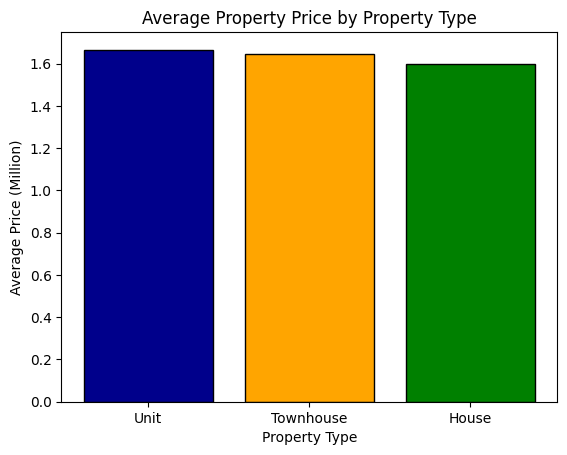

In [23]:
property_type = {'h': 'House', 'u': 'Unit', 't': 'Townhouse'}
avg_price = (melb_df.groupby('Type')['Price'].mean().round().sort_values(ascending=False))
avg_price.index = avg_price.index.map(property_type)

bars = plt.bar( avg_price.index, avg_price.values / 1000000,color=['darkblue', 'orange', 'green'],edgecolor='black')

plt.title('Average Property Price by Property Type')
plt.xlabel('Property Type')
plt.ylabel('Average Price (Million)')
plt.show()

**Observation**
Unit has the highest average property price at 1,665,359, followed by Townhouse at 1,645,089.
House records the lowest average property price among the three types at 1,595,490.

**Insight**
The higher average price of Units suggests that many units in this dataset are located in premium urban areas where demand and property values are higher than in suburban house markets.

**Recommendation**
Investors seeking higher-value properties may consider Units, as they show the highest average price of 1,665,359.
Further analysis should examine factors such as location, land size, and number of rooms to understand the price differences.

#### Q2.How does the number of rooms affect property prices?

In [24]:
avg_price_by_rooms = ( melb_df.groupby('Rooms')['Price'].mean().round().sort_values().sort_values(ascending=False))
avg_price_by_rooms

Rooms
5    1692348.0
1    1673598.0
3    1657501.0
2    1606319.0
4    1596354.0
6    1584500.0
Name: Price, dtype: float64

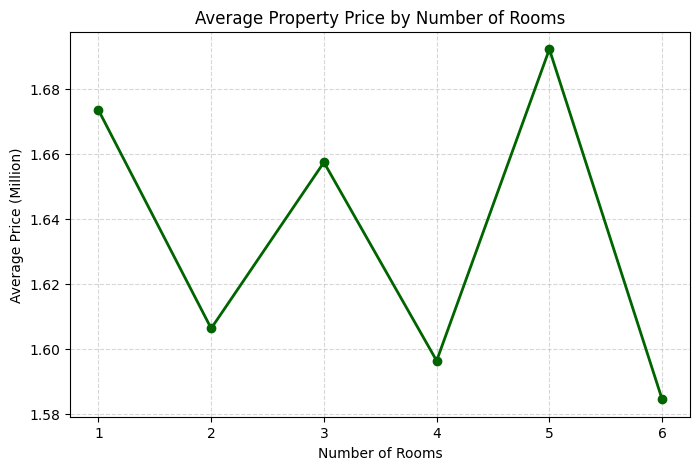

In [25]:
avg_price_rooms = (  melb_df.groupby('Rooms')['Price'].mean().round())

plt.figure(figsize=(8,5))
plt.plot(  avg_price_rooms.index,avg_price_rooms.values / 1000000,color='darkgreen',marker='o',linewidth=2)
plt.title('Average Property Price by Number of Rooms')
plt.xlabel('Number of Rooms')
plt.ylabel('Average Price (Million)')

plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Observation**
Properties with 5 Rooms have the highest average price at 1,692,348, while 6 Rooms properties have the lowest average price at 1,584,500.
1 Room and 3 Rooms properties also show high average prices of 1,673,598 and 1,657,501, respectively.

**Insight**
Property prices do not increase consistently with the number of rooms, as 5 Rooms properties are priced higher than 6 Rooms properties.
The price difference between the highest-priced (5 Rooms) and lowest-priced (6 Rooms) properties is 107,848.

**Recommendation**
Buyers seeking higher-value properties may focus on 5 Rooms properties, which have the highest average price of 1,692,348.
Additional factors such as Suburb, Landsize, and Property Type should be analyzed since room count alone does not explain property prices.

#### Q3.Does distance from the city influence property price?

In [26]:
# Create distance groups (bins)
melb_df['Distance_Group'] = pd.cut(
    melb_df['Distance'],
    bins=[0, 5, 10, 15, 20, 25, 35],
    labels=['0-5km', '5-10km', '10-15km', '15-20km', '20-30km', '30-50km'])

# Average price by distance group
avg_price_distance = ( melb_df.groupby('Distance_Group')['Price'] .mean() .round())
avg_price_distance

Distance_Group
0-5km      1619396.0
5-10km     1601893.0
10-15km    1661530.0
15-20km    1602471.0
20-30km    1671880.0
30-50km    1646113.0
Name: Price, dtype: float64

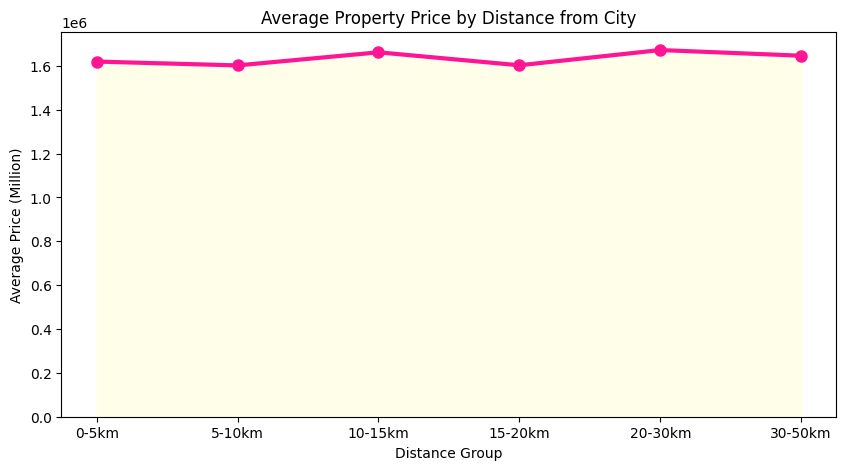

In [27]:
melb_df['Distance_Group'] = pd.cut( melb_df['Distance'],
    bins=[0, 5, 10, 15, 20, 25, 35],
    labels=['0-5km', '5-10km', '10-15km', '15-20km', '20-30km', '30-50km'])

avg_price_distance = (melb_df.groupby('Distance_Group')['Price'].mean().round())

plt.figure(figsize=(10,5))
avg_price_distance.plot(kind='area',alpha=0.7,color='lightyellow')
plt.plot(avg_price_distance.index,avg_price_distance.values,color='deeppink',marker='o',linewidth=3,markersize=8)
plt.title('Average Property Price by Distance from City')
plt.xlabel('Distance Group')
plt.ylabel('Average Price (Million)')
plt.show()

**Observation**
Properties in the 20-30km distance group have the highest average price at 1,671,880, while the 5-10km group has the lowest average price at 1,601,893.
Property prices across all distance groups remain relatively close, ranging from 1,601,893 to 1,671,880.

**Insight**
Properties farther from the city do not necessarily have lower prices, as the 20-30km group records a higher average price than closer distance groups.
The difference between the highest and lowest average price is only 69,987, indicating a weak relationship between distance and property price

**Recommendation**
Distance alone should not be used to evaluate property value, as higher-priced properties are found in both near and far distance groups.
Additional factors such as Suburb, Property Type, Landsize, and Number of Rooms should be analyzed to better understand price variations.

#### Q4.How does land size affect property price?

In [28]:
melb_df['Land_Group'] = pd.cut(
    melb_df['Landsize'],
    bins=[0, 250, 500, 750, 1000, 5000],
    labels=['0-250', '250-500', '500-750', '750-1000', '1000+'])

avg_price_land = ( melb_df.groupby('Land_Group')['Price'].mean().round().sort_values(ascending=True))
avg_price_land

Land_Group
0-250       1535561.0
500-750     1599893.0
250-500     1630659.0
750-1000    1641219.0
1000+       1643833.0
Name: Price, dtype: float64

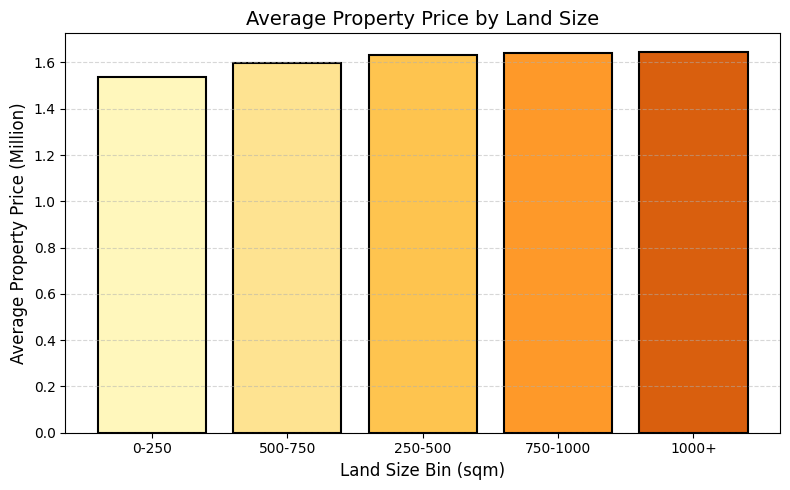

In [29]:
melb_df['Land_Group'] = pd.cut(
    melb_df['Landsize'],
    bins=[0, 250, 500, 750, 1000, 5000],
    labels=['0-250', '250-500', '500-750', '750-1000', '1000+'])

avg_price_land = (melb_df.groupby('Land_Group')['Price'].mean().round().sort_values(ascending=True))

colors = ['#fff7bc', '#fee391', '#fec44f', '#fe9929', '#d95f0e']
plt.figure(figsize=(8,5))
bars = plt.bar(avg_price_land.index,avg_price_land.values / 1000000, color=colors,edgecolor='black',linewidth=1.5)

plt.title('Average Property Price by Land Size', fontsize=14)
plt.xlabel('Land Size Bin (sqm)', fontsize=12)
plt.ylabel('Average Property Price (Million)', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Observation**
Properties in the 1000+ sqm land size bin recorded the highest average price of 1,643,833.
Properties in the 0-250 sqm land size bin had the lowest average price of 1,535,561.
The average property price generally increases as the land size bin becomes larger.
The price difference between the smallest and largest land size bins is approximately 108,272.

**Insight**
Larger land parcels tend to be associated with higher property values.
The increase in average price is gradual across the land size bins rather than dramatic.
Properties with land sizes above 750 sqm show relatively similar average prices, suggesting diminishing returns from additional land area.

**Recommendation**
Buyers seeking higher-value properties may consider larger land size categories, particularly 1000+ sqm.
Developers and investors can target larger land parcels, as they generally command premium prices.
Further analysis with other factors such as Location, Rooms, and Building Area may reveal stronger drivers of property prices than land size alone.

#### Q5. Which region has the highest average property price?

In [30]:
avg_price_region = (  melb_df.groupby('Regionname')['Price'].mean().round().sort_values(ascending=False))
avg_price_region

Regionname
South-Eastern Metropolitan    1692118.0
Western Metropolitan          1631225.0
Eastern Metropolitan          1620610.0
Southern Metropolitan         1616398.0
Northern Metropolitan         1614015.0
Name: Price, dtype: float64

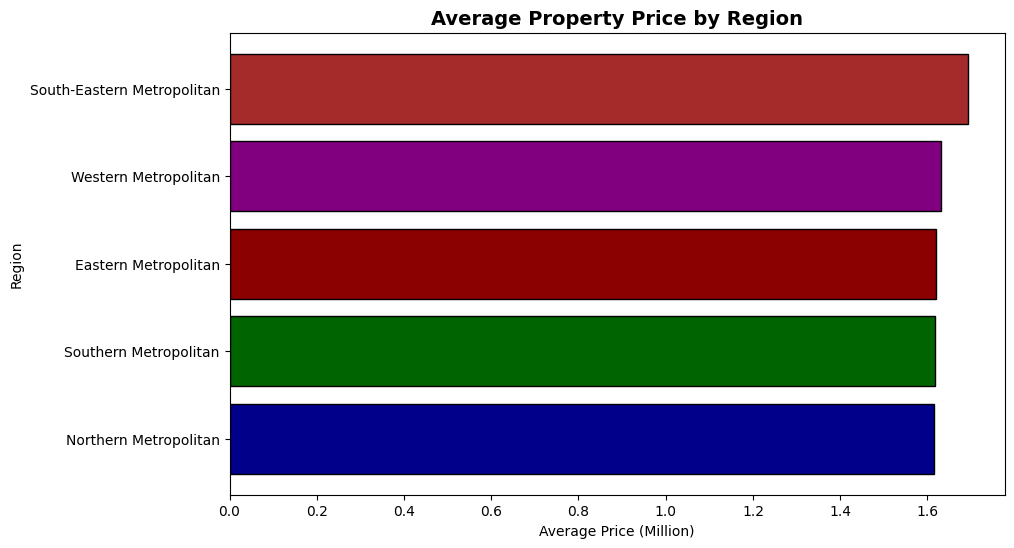

In [31]:
avg_price_region = ( melb_df.groupby('Regionname')['Price'].mean().round().sort_values())

plt.figure(figsize=(10, 6))
bars = plt.barh(avg_price_region.index, avg_price_region.values / 1000000,
                color=['darkblue', 'darkgreen', 'darkred', 'purple', 'brown', 'black', 'navy'],edgecolor='black')

plt.title('Average Property Price by Region', fontsize=14, fontweight='bold')
plt.xlabel('Average Price (Million)')
plt.ylabel('Region')
plt.show()

**Observation**
The South-Eastern Metropolitan region recorded the highest average property price of 1,692,118.
The Western Metropolitan region ranked second with an average price of 1,631,225.
The Northern Metropolitan region had the lowest average property price of 1,614,015.
The difference between the highest and lowest priced regions is approximately 78,103

**Insight**
Property prices are relatively similar across metropolitan regions, with only moderate variation.
The South-Eastern Metropolitan region appears to be the most premium housing market in the dataset.
Regional location has an impact on property prices, although the gap between regions is not substantial.

**Recommendation**
Buyers seeking premium residential properties may focus on the South-Eastern Metropolitan region.
Investors looking for relatively lower entry prices may explore the Northern Metropolitan region.
Additional factors such as Suburb, Distance, WalkScore, and Property Type should be analyzed alongside region to better understand property price differences.

#### Q6. Are newer houses more expensive than older houses?

In [32]:
# Create house age groups
melb_df['House_Age'] = pd.cut( melb_df['YearBuilt'],
    bins=[1800, 1950, 1980, 2000, 2025],
    labels=['Old', 'Mid-Age', 'Modern', 'New'])

avg_price_age = (melb_df.groupby('House_Age')['Price'].mean().round().sort_values(ascending=False))
avg_price_age

House_Age
Modern     1759287.0
Old        1644618.0
Mid-Age    1552880.0
New        1507750.0
Name: Price, dtype: float64

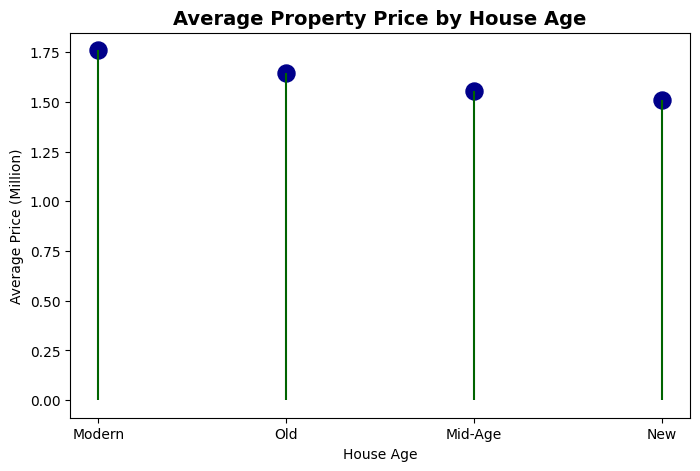

In [33]:
melb_df['House_Age'] = pd.cut( melb_df['YearBuilt'],
    bins=[1800, 1950, 1980, 2000, 2025],
    labels=['Old', 'Mid-Age', 'Modern', 'New'])

avg_price_age = (melb_df.groupby('House_Age')['Price'].mean().round().sort_values(ascending=False))

plt.figure(figsize=(8,5))
plt.vlines( x=avg_price_age.index,ymin=0,ymax=avg_price_age.values/1000000,color='darkgreen')

plt.scatter(avg_price_age.index,avg_price_age.values/1000000,color='darkblue',s=150)
plt.title('Average Property Price by House Age', fontsize=14, fontweight='bold')
plt.xlabel('House Age')
plt.ylabel('Average Price (Million)')
plt.show()

**Observation**
Modern houses have the highest average price at 1,759,287.
New houses have the lowest average price at 1,507,750

**Insight**
Property prices do not consistently increase with newer houses.
Modern houses are priced about 251,537 higher than New houses.

**Recommendation**
Buyers looking for higher-value properties may consider Modern houses, as they have the highest average price.
Developers should investigate why New houses have a lower average price than Modern houses despite being newer. 

#### Q7. How does the average property price vary based on the availability of nearby schools and hospitals?

In [38]:
avg_price_facilities = (melb_df.groupby([ 'HospitalNearby'])['Price'].mean().round())
avg_price_facilities

HospitalNearby
No     1644625.0
Yes    1627426.0
Name: Price, dtype: float64

In [39]:
avg_price_facilities = (melb_df.groupby(['SchoolNearby'])['Price'].mean().round())
avg_price_facilities

SchoolNearby
No     1607077.0
Yes    1656213.0
Name: Price, dtype: float64

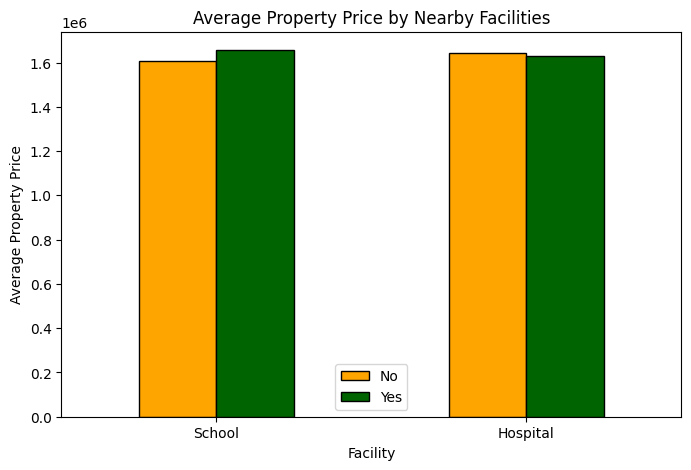

In [41]:
school_price = melb_df.groupby('SchoolNearby')['Price'].mean().round()
hospital_price = melb_df.groupby('HospitalNearby')['Price'].mean().round()

data = pd.DataFrame({'School': school_price,'Hospital': hospital_price})
data = data.T

data.plot(kind='bar',figsize=(8,5),color=['orange','darkgreen'],edgecolor='black')

plt.title('Average Property Price by Nearby Facilities')
plt.xlabel('Facility')
plt.ylabel('Average Property Price')
plt.xticks(rotation=0)
plt.show()

**Observation**
Properties with SchoolNearby = Yes have a higher average price (1,656,213) than those with SchoolNearby = No (1,607,077).
Properties with HospitalNearby = No have a slightly higher average price (1,644,625) than HospitalNearby = Yes (1,627,426).

**Insight**
Nearby schools appear to have a positive impact on property prices, increasing the average price by about 49,136.
Nearby hospitals show a small negative difference of about 17,199, indicating limited influence on price.

**Recommendation**
Buyers looking for better long-term property value may prioritize locations near schools.
Developers should focus more on school accessibility, as it appears to contribute more to property prices than hospital proximity.

#### Q8.Which Suburbs Have the Highest Median Property Prices?

In [42]:
suburb_price = (melb_df.groupby('Suburb')['Price'].median().sort_values(ascending=False))
suburb_price

Suburb
Essendon        1707913.00
St Kilda        1693401.00
Brunswick       1650973.50
Coburg          1650973.50
Collingwood     1650973.50
Hawthorn        1650973.50
Malvern         1650973.50
Moonee Ponds    1650973.50
Northcote       1650973.50
Preston         1650973.50
Richmond        1646102.00
South Yarra     1644975.25
Camberwell      1638060.25
Reservoir       1620878.00
Fitzroy         1585095.00
Name: Price, dtype: float64

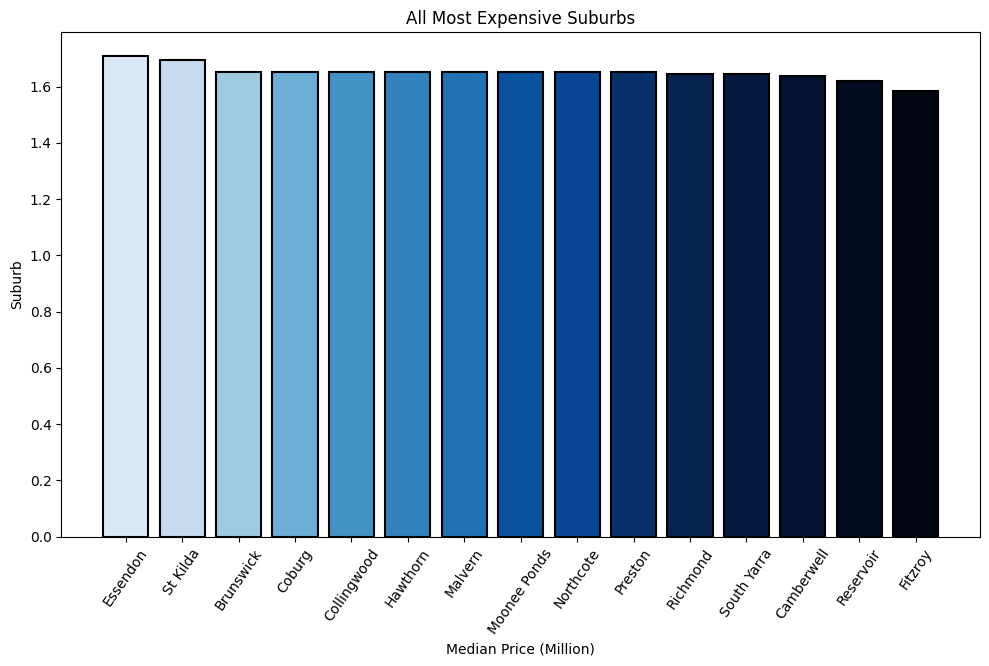

In [43]:
suburb_price = (melb_df.groupby('Suburb')['Price'].median().sort_values(ascending=False))


colors = ['#dbe9f6', '#c6dbef', '#9ecae1', '#6baed6','#4292c6', '#3182bd', '#2171b5', '#08519c',
          '#084594', '#08306b', '#082252', '#06193f','#04122f', '#020b1f', '#000510']

plt.figure(figsize=(10,6))
plt.bar( suburb_price.index, suburb_price.values / 1000000,
    color=colors,edgecolor='black',linewidth=1.5)
plt.title('All Most Expensive Suburbs')
plt.xlabel('Median Price (Million)')
plt.ylabel('Suburb')
plt.tight_layout()
plt.xticks(rotation=55)
plt.show()

**Observation:**
Essendon recorded the highest median property price at 1,707,913, while Fitzroy had the lowest among the top 15 suburbs at 1,585,095. Most top suburbs have median prices between 1.58M and 1.71M.

**Insight:**
The price difference among the top 15 suburbs is relatively small, indicating consistently high property values across these premium locations.

**Recommendation:**
Buyers seeking long-term value can target suburbs like Essendon and St Kilda, while investors may explore other top-ranked suburbs that offer similar pricing with potential growth opportunities.

# **Key Suggestion Based on Melbourne Housing Market Analysis----------------**

**1. Focus on High-Value Suburbs**
Buyers and investors should prioritize suburbs with consistently higher median property prices, as these areas demonstrate stronger market demand and potential long-term value appreciation.

**2. Consider Property Size Before Investment**
Properties with larger land sizes and more bedrooms generally command higher prices. Investors can use these features as key indicators when evaluating property value.

**3. Evaluate Location Carefully**
Distance from Melbourne's city center significantly impacts housing prices. Buyers should balance affordability with accessibility when selecting properties.

**4. Prioritize Areas with Better Amenities**
Suburbs with better access to schools, hospitals, and public facilities tend to attract more buyers and maintain stronger property values.

**5. Use Data-Driven Decision Making**
Real estate decisions should be supported by market data, property characteristics, and location analysis rather than relying solely on market trends or assumptions.

**6. Monitor Market Trends Regularly**
Property prices vary across suburbs and property types. Continuous monitoring of housing trends can help investors identify profitable opportunities and reduce investment risks.

# *Final Conclusion------------------------------*

The Melbourne Housing Price Analysis shows that property prices are influenced by multiple factors, including location, property size, number of rooms, and nearby amenities. Suburbs with better infrastructure and accessibility generally have higher housing prices. Larger properties with more bedrooms, bathrooms, and parking spaces also tend to be more expensive. Additionally, proximity to schools and hospitals can positively impact property values. These insights help buyers, sellers, and investors better understand market trends and make informed real estate decisions.